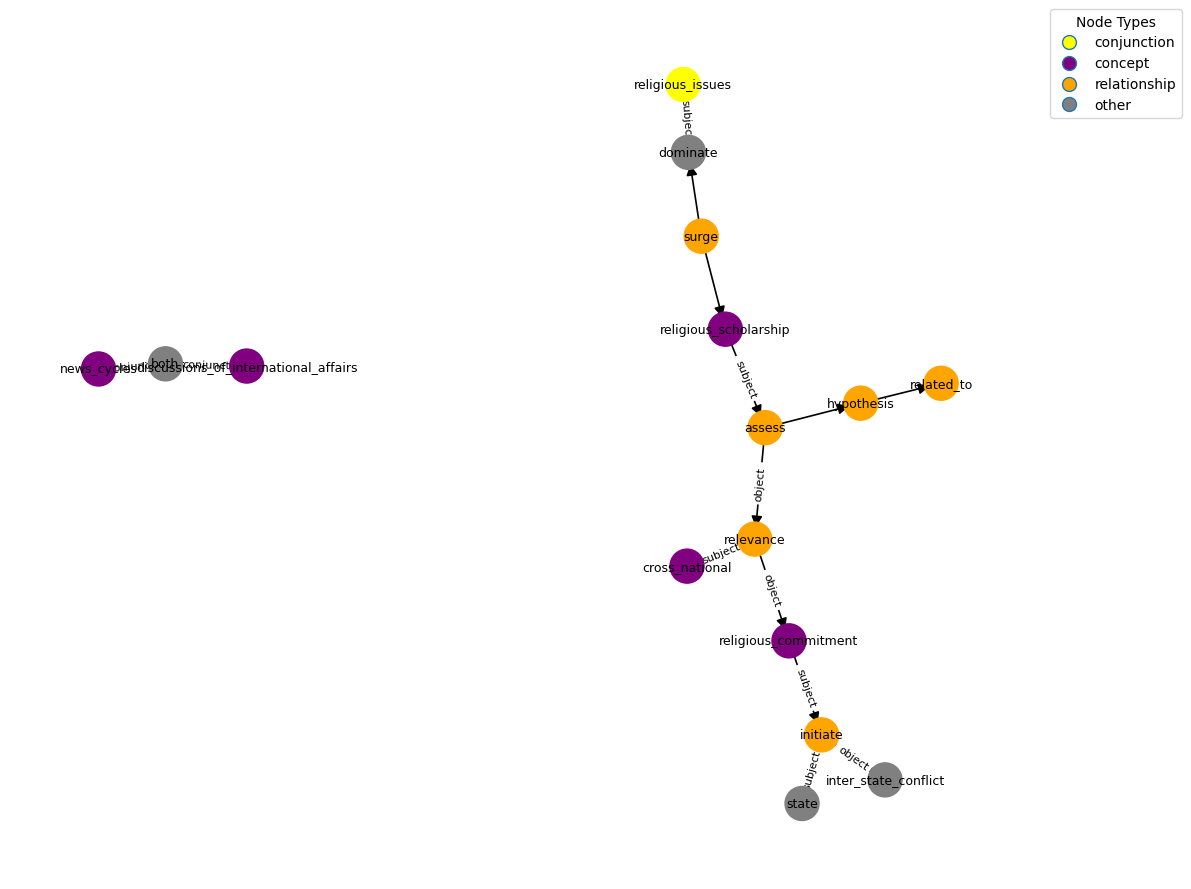

Loaded graph: Graph
Nodes: 16 | Edges: 14
Saved image to: /Users/nickpellegri/Documents/Github/w0rldview/graphML.png


In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

# GraphML file path
#GRAPHML_PATH = Path(r"C:\WorldView\worldview\w0rldview\test1_v2.graphml")   # Windows
GRAPHML_PATH = Path("/Users/nickpellegri/Documents/Github/w0rldview/test1_v2.graphml")    # Mac

NODE_LABEL_ATTR = None
EDGE_LABEL_ATTR = "Edge_Type"
NODE_TYPE_ATTR = "Node_Type"

OUT_IMAGE = Path("graphML.png")

def main():
    if not GRAPHML_PATH.exists():
        raise FileNotFoundError(f"GraphML file not found: {GRAPHML_PATH}")

    G = nx.read_graphml(GRAPHML_PATH)
    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(12, 9))

    # --- Node color by type ---
    node_type_colors = {
        "concept": "purple",
        "people": "blue",
        "location": "green",
        "conjunction": "yellow",
        "relationship": "orange",
        #"subject": "red",
        "target": "red",
        "other": "gray",
    }

    # --- Build node color list ---
    node_colors = []
    for n in G.nodes():
        t = str(G.nodes[n].get(NODE_TYPE_ATTR, "other")).strip().lower()
        node_colors.append(node_type_colors.get(t, node_type_colors["other"]))

    # --- Draw nodes ---
    nx.draw_networkx_nodes(
        G, pos,
        node_size=600,
        node_color=node_colors
    )

    # --- Draw edges with arrowheads ---
    nx.draw_networkx_edges(
        G, pos,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=16,
        width=1.2
    )

    # --- Node labels ---
    if NODE_LABEL_ATTR:
        node_labels = {n: str(G.nodes[n].get(NODE_LABEL_ATTR, n)) for n in G.nodes()}
    else:
        node_labels = {n: str(n) for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=9)

    # --- Edge labels ---
    if EDGE_LABEL_ATTR:
        edge_labels = {}
        if G.is_multigraph():
            for u, v, k, data in G.edges(keys=True, data=True):
                if EDGE_LABEL_ATTR in data:
                    edge_labels[(u, v)] = str(data[EDGE_LABEL_ATTR])
        else:
            for u, v, data in G.edges(data=True):
                if EDGE_LABEL_ATTR in data:
                    edge_labels[(u, v)] = str(data[EDGE_LABEL_ATTR])

        if edge_labels:
            nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    # --- Legend ---
    present_types = []
    for n in G.nodes():
        t = str(G.nodes[n].get(NODE_TYPE_ATTR, "other")).strip().lower()
        if t not in present_types:
            present_types.append(t)

    legend_handles = []
    for t in present_types:
        c = node_type_colors.get(t, node_type_colors["other"])
        legend_handles.append(
            Line2D([0], [0], marker='o', linestyle='',
                   markerfacecolor=c, markersize=10, label=t)
        )

    if legend_handles:
        plt.legend(handles=legend_handles, title="Node Types",
                   loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)

    plt.axis("off")
    plt.tight_layout()
    plt.savefig(OUT_IMAGE, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Loaded graph: {G.__class__.__name__}")
    print(f"Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")
    print(f"Saved image to: {OUT_IMAGE.resolve()}")

if __name__ == "__main__":
    main()

In [ ]:
#COMPARE TWO GRAPHS
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path


def compare_graphml_files(file1, file2):
    file1 = Path(file1)
    file2 = Path(file2)

    # Check files exist
    if not file1.exists():
        print(f"File not found: {file1}")
        return
    if not file2.exists():
        print(f"File not found: {file2}")
        return

    # Load graphs
    try:
        G1 = nx.read_graphml(file1)
        G2 = nx.read_graphml(file2)
    except Exception as e:
        print(f"Error reading GraphML files: {e}")
        return

    print(f"\nLoaded Graph 1: {file1.name}")
    print(f"Loaded Graph 2: {file2.name}")

    
    # Compare nodes
    nodes1 = set(G1.nodes())
    nodes2 = set(G2.nodes())

    matching_nodes = nodes1 & nodes2
    nodes_only_in_G1 = nodes1 - nodes2
    nodes_only_in_G2 = nodes2 - nodes1

    print("\n--- NODE COMPARISON ---")
    if matching_nodes:
        print("Matching nodes:")
        for node in sorted(matching_nodes):
            print(f"  {node}")
    else:
        print("No matching nodes found.")

    if nodes_only_in_G1:
        print("\nNodes only in first graph:")
        for node in sorted(nodes_only_in_G1):
            print(f"  {node}")

    if nodes_only_in_G2:
        print("\nNodes only in second graph:")
        for node in sorted(nodes_only_in_G2):
            print(f"  {node}")

    
    # Compare edges
    edges1 = set(G1.edges())
    edges2 = set(G2.edges())

    matching_edges = edges1 & edges2
    edges_only_in_G1 = edges1 - edges2
    edges_only_in_G2 = edges2 - edges1

    print("\n--- EDGE COMPARISON ---")
    if matching_edges:
        print("Matching edges:")
        for edge in sorted(matching_edges):
            print(f"  {edge}")
    else:
        print("No matching edges found.")

    if edges_only_in_G1:
        print("\nEdges only in first graph:")
        for edge in sorted(edges_only_in_G1):
            print(f"  {edge}")

    if edges_only_in_G2:
        print("\nEdges only in second graph:")
        for edge in sorted(edges_only_in_G2):
            print(f"  {edge}")

    
    # Summary
    print("\n--- SUMMARY ---")
    print(f"Graph 1: {G1.number_of_nodes()} nodes, {G1.number_of_edges()} edges")
    print(f"Graph 2: {G2.number_of_nodes()} nodes, {G2.number_of_edges()} edges")

    if nodes1 == nodes2 and edges1 == edges2:
        print("The two graphs are structurally identical.")
    else:
        print("The two graphs are NOT structurally identical.")

    # Visual comparison
    # Match layout: compute positions from Graph1 and map them to Graph2
    pos1 = nx.spring_layout(G1, seed=42)
    # Initialize pos2 with pos1 so shared nodes keep the same positions
    pos2_init = pos1.copy()
    # Keep nodes from G1 fixed, compute positions for remaining nodes in G2
    fixed_nodes = list(pos1.keys())
    pos2 = nx.spring_layout(G2, pos=pos2_init, fixed=fixed_nodes, seed=42)

    # -------- Graph 1 (separate figure) --------
    plt.figure(figsize=(10, 8))
    g1_match_nodes = list(matching_nodes)
    g1_unique_nodes = list(nodes_only_in_G1)

    g1_match_edges = list(matching_edges)
    g1_unique_edges = list(edges_only_in_G1)

    nx.draw_networkx_edges(G1, pos1, edgelist=g1_match_edges, width=2)
    nx.draw_networkx_edges(G1, pos1, edgelist=g1_unique_edges, width=2.5, style="dashed")

    nx.draw_networkx_nodes(G1, pos1, nodelist=g1_match_nodes, node_size=900)
    nx.draw_networkx_nodes(G1, pos1, nodelist=g1_unique_nodes, node_size=900)

    nx.draw_networkx_labels(G1, pos1, font_size=9)
    plt.title("Graph 1")
    plt.axis("off")
    plt.figtext(0.5, 0.01, "Matching nodes/edges = solid | Unique nodes/edges = dashed", ha="center", fontsize=10)
    plt.tight_layout()
    plt.show()

    # -------- Graph 2 (separate figure) --------
    plt.figure(figsize=(10, 8))
    g2_match_nodes = list(matching_nodes)
    g2_unique_nodes = list(nodes_only_in_G2)

    g2_match_edges = list(matching_edges)
    g2_unique_edges = list(edges_only_in_G2)

    nx.draw_networkx_edges(G2, pos2, edgelist=g2_match_edges, width=2)
    nx.draw_networkx_edges(G2, pos2, edgelist=g2_unique_edges, width=2.5, style="dashed")

    nx.draw_networkx_nodes(G2, pos2, nodelist=g2_match_nodes, node_size=900)
    nx.draw_networkx_nodes(G2, pos2, nodelist=g2_unique_nodes, node_size=900)

    nx.draw_networkx_labels(G2, pos2, font_size=9)
    plt.title("Graph 2")
    plt.axis("off")
    plt.figtext(0.5, 0.01, "Matching nodes/edges = solid | Unique nodes/edges = dashed", ha="center", fontsize=10)
    plt.tight_layout()
    plt.show()


# GraphML file paths
#file1 = r"C:\WorldView\worldview\w0rldview\test2.graphml"  # Mac & Windows
#file2 = r"C:\WorldView\worldview\w0rldview\test1.graphml"  # Mac & Windows
file1 = "/Users/nickpellegri/Documents/Github/w0rldview/test2.graphml"  # Mac
file2 = "/Users/nickpellegri/Documents/Github/w0rldview/test1.graphml"  # Mac

compare_graphml_files(file1, file2)

In [ ]:
#COMPARE TWO GRAPHS INTERACTIVE
import networkx as nx
from pathlib import Path
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from dash import Dash, dcc, html, Input, Output
from dash.exceptions import PreventUpdate



# FILE PATHS MAC
file1 = "/Users/nickpellegri/Documents/Github/w0rldview/test2.graphml"  # Mac
file2 = "/Users/nickpellegri/Documents/Github/w0rldview/test1.graphml"  # Mac

# FILE PATHS WINDOWS
# file1 = r"C:\WorldView\worldview\w0rldview\test2.graphml"
# file2 = r"C:\WorldView\worldview\w0rldview\test1.graphml"



# LOAD + COMPARE
def load_graphs(file1, file2):
    file1 = Path(file1)
    file2 = Path(file2)

    if not file1.exists():
        raise FileNotFoundError(f"File not found: {file1}")
    if not file2.exists():
        raise FileNotFoundError(f"File not found: {file2}")

    G1 = nx.read_graphml(file1)
    G2 = nx.read_graphml(file2)

    nodes1 = set(G1.nodes())
    nodes2 = set(G2.nodes())

    matching_nodes = nodes1 & nodes2
    nodes_only_in_G1 = nodes1 - nodes2
    nodes_only_in_G2 = nodes2 - nodes1

    edges1 = set(G1.edges())
    edges2 = set(G2.edges())

    matching_edges = edges1 & edges2
    edges_only_in_G1 = edges1 - edges2
    edges_only_in_G2 = edges2 - edges1

    return {
        "G1": G1,
        "G2": G2,
        "matching_nodes": matching_nodes,
        "nodes_only_in_G1": nodes_only_in_G1,
        "nodes_only_in_G2": nodes_only_in_G2,
        "matching_edges": matching_edges,
        "edges_only_in_G1": edges_only_in_G1,
        "edges_only_in_G2": edges_only_in_G2,
        "file1_name": file1.name,
        "file2_name": file2.name,
    }


data = load_graphs(file1, file2)

G1 = data["G1"]
G2 = data["G2"]

matching_nodes = data["matching_nodes"]
nodes_only_in_G1 = data["nodes_only_in_G1"]
nodes_only_in_G2 = data["nodes_only_in_G2"]

matching_edges = data["matching_edges"]
edges_only_in_G1 = data["edges_only_in_G1"]
edges_only_in_G2 = data["edges_only_in_G2"]



# LAYOUT POSITIONS
# Use Graph1 layout as base so shared nodes line up similarly
pos1 = nx.spring_layout(G1, seed=42)

# Only fix nodes that are in both graphs
shared_fixed_nodes = [n for n in G2.nodes() if n in pos1]

# Start Graph2 with positions from shared nodes only
pos2_init = {n: pos1[n] for n in shared_fixed_nodes}

pos2 = nx.spring_layout(
    G2,
    pos=pos2_init if pos2_init else None,
    fixed=shared_fixed_nodes if shared_fixed_nodes else None,
    seed=42
)


# PLOT HELPERS
def edge_trace_for_subset(G, pos, edge_subset, name, color, dash_style, xaxis, yaxis):
    x_vals = []
    y_vals = []

    for u, v in edge_subset:
        if u in pos and v in pos:
            x0, y0 = pos[u]
            x1, y1 = pos[v]
            x_vals.extend([x0, x1, None])
            y_vals.extend([y0, y1, None])

    return go.Scatter(
        x=x_vals,
        y=y_vals,
        mode="lines",
        line=dict(width=2, color=color, dash=dash_style),
        hoverinfo="skip",
        name=name,
        xaxis=xaxis,
        yaxis=yaxis,
        showlegend=True
    )


def node_trace_for_subset(G, pos, node_subset, name, color, symbol, xaxis, yaxis):
    x_vals = []
    y_vals = []
    text_vals = []

    for node in node_subset:
        if node in pos:
            x, y = pos[node]
            x_vals.append(x)
            y_vals.append(y)
            text_vals.append(str(node))

    return go.Scatter(
        x=x_vals,
        y=y_vals,
        mode="markers+text",
        text=text_vals,
        textposition="top center",
        hovertemplate="Node: %{text}<extra></extra>",
        marker=dict(
            size=20,
            color=color,
            symbol=symbol,
            line=dict(width=1, color="black")
        ),
        name=name,
        xaxis=xaxis,
        yaxis=yaxis,
        showlegend=True
    )


def build_figure(show_options):
    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=(data["file1_name"], data["file2_name"]),
        horizontal_spacing=0.08
    )

    # ----- Graph 1 ----------
    traces = []

    if "matching_edges" in show_options:
        traces.append(
            edge_trace_for_subset(
                G1, pos1, matching_edges,
                "Graph 1 - Matching Edges", "gray", "solid", "x1", "y1"
            )
        )

    if "unique_edges_g1" in show_options:
        traces.append(
            edge_trace_for_subset(
                G1, pos1, edges_only_in_G1,
                "Graph 1 - Unique Edges", "red", "dash", "x1", "y1"
            )
        )

    if "matching_nodes" in show_options:
        traces.append(
            node_trace_for_subset(
                G1, pos1, matching_nodes,
                "Graph 1 - Matching Nodes", "lightblue", "circle", "x1", "y1"
            )
        )

    if "unique_nodes_g1" in show_options:
        traces.append(
            node_trace_for_subset(
                G1, pos1, nodes_only_in_G1,
                "Graph 1 - Unique Nodes", "orange", "diamond", "x1", "y1"
            )
        )

    for tr in traces:
        fig.add_trace(tr, row=1, col=1)

    # ------ Graph 2 ---------
    traces = []

    if "matching_edges" in show_options:
        traces.append(
            edge_trace_for_subset(
                G2, pos2, matching_edges,
                "Graph 2 - Matching Edges", "gray", "solid", "x2", "y2"
            )
        )

    if "unique_edges_g2" in show_options:
        traces.append(
            edge_trace_for_subset(
                G2, pos2, edges_only_in_G2,
                "Graph 2 - Unique Edges", "red", "dash", "x2", "y2"
            )
        )

    if "matching_nodes" in show_options:
        traces.append(
            node_trace_for_subset(
                G2, pos2, matching_nodes,
                "Graph 2 - Matching Nodes", "lightblue", "circle", "x2", "y2"
            )
        )

    if "unique_nodes_g2" in show_options:
        traces.append(
            node_trace_for_subset(
                G2, pos2, nodes_only_in_G2,
                "Graph 2 - Unique Nodes", "orange", "diamond", "x2", "y2"
            )
        )

    for tr in traces:
        fig.add_trace(tr, row=1, col=2)

    fig.update_layout(
        title="Interactive Graph Comparison",
        height=800,
        width=1400,
        legend=dict(orientation="h", y=-0.1),
        margin=dict(l=20, r=20, t=70, b=80)
    )

    fig.update_xaxes(visible=False)
    fig.update_yaxes(visible=False)

    return fig



# DASH APP
app = Dash(__name__)

app.layout = html.Div([
    html.H2("Compare Two GraphML Files"),

    html.Div([
        dcc.Checklist(
            id="toggle-options",
            options=[
                {"label": " Show Matching Nodes", "value": "matching_nodes"},
                {"label": " Show Unique Nodes in Graph 1", "value": "unique_nodes_g1"},
                {"label": " Show Unique Nodes in Graph 2", "value": "unique_nodes_g2"},
                {"label": " Show Matching Edges", "value": "matching_edges"},
                {"label": " Show Unique Edges in Graph 1", "value": "unique_edges_g1"},
                {"label": " Show Unique Edges in Graph 2", "value": "unique_edges_g2"},
            ],
            value=[
                "matching_nodes",
                "unique_nodes_g1",
                "unique_nodes_g2",
                "matching_edges",
                "unique_edges_g1",
                "unique_edges_g2",
            ],
            inline=False
        )
    ], style={"marginBottom": "20px"}),

    html.Div(id="summary-text", style={"marginBottom": "15px", "fontWeight": "bold"}),

    dcc.Graph(id="graph-comparison")
])


@app.callback(
    Output("graph-comparison", "figure"),
    Output("summary-text", "children"),
    Input("toggle-options", "value")
)
def update_graph(selected_options):
    if selected_options is None:
        raise PreventUpdate

    figure = build_figure(set(selected_options))

    summary = (
        f"Graph 1: {G1.number_of_nodes()} nodes, {G1.number_of_edges()} edges | "
        f"Graph 2: {G2.number_of_nodes()} nodes, {G2.number_of_edges()} edges | "
        f"Matching nodes: {len(matching_nodes)} | "
        f"Matching edges: {len(matching_edges)}"
    )

    return figure, summary


if __name__ == "__main__":
    app.run(debug=True)